In [1]:
# ============================================================
# 06 - COMPARACIÓN DE MODELOS (Caso 15 - Servicio Ciudadano 1800)
# Mismo procedimiento del ejemplo del profe: se prueban varios
# algoritmos con el MISMO dataset y al final se hace la tabla
# comparativa para ver quién obtuvo los mejores resultados.
# Target: recontacto_7_dias (1 = vuelve a contactar en 7 días)
# ============================================================
import os
import sys
import time
import warnings

warnings.filterwarnings('ignore')

# Ruta al proyecto de analítica (funciona local y dentro de Docker)
RUTA_ANALITICA = None
for candidata in (
    os.path.abspath('DataSetGenerator/servicio-ciudadano-analytics'),
    os.path.abspath('../DataSetGenerator/servicio-ciudadano-analytics'),
    os.path.abspath('..'),
    os.path.abspath('.'),
):
    if os.path.isfile(os.path.join(candidata, 'cargar_datos.py')):
        RUTA_ANALITICA = candidata
        break
if RUTA_ANALITICA is None:
    raise FileNotFoundError('No se encontró cargar_datos.py (¿está el proyecto de analítica?)')
for ruta in (RUTA_ANALITICA, os.path.join(RUTA_ANALITICA, 'src')):
    if ruta not in sys.path:
        sys.path.insert(0, ruta)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cargar_datos import cargar_dataset_recontacto_correcto

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAY_LIGHTGBM = True
except Exception as e:
    HAY_LIGHTGBM = False
    print('LightGBM no disponible, se omite:', e)

from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Todas las librerías cargadas")


✅ Todas las librerías cargadas


In [2]:
# Cargar el dataset CORREGIDO (limpio, después del MINI ETL)
df = cargar_dataset_recontacto_correcto()

# Separar features y target (se quitan id y fecha: no predicen)
columnas_a_eliminar = ['id_interaccion', 'fecha_contacto', 'recontacto_7_dias']
X = df.drop(columns=columnas_a_eliminar, errors='ignore').apply(pd.to_numeric)
y = df['recontacto_7_dias'].astype(int)

# Convertir booleanos y rellenar nulos
X = X.astype({col: 'int8' for col in X.select_dtypes(include=['bool']).columns})
X = X.fillna(0)

# División train/test estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Escalado (necesario para Regresión Logística, KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dataset listo: {X_train.shape[0]:,} train, {X_test.shape[0]:,} test")
print(f"📊 Features: {X.shape[1]}")


📊 CARGANDO DATASET v1 CORREGIDO DE RECONTACTO (LIMPIO)



📏 Dataset v1 (limpio): 94,065 filas × 29 columnas

🎯 Distribución de la variable objetivo (recontacto_7_dias):
recontacto_7_dias
0    55324
1    38741
Name: count, dtype: int64

📈 Tasa de recontacto_7_dias=1: 41.19%


✅ Dataset listo: 75,252 train, 18,813 test
📊 Features: 26


In [3]:
# Ratio de desbalance (clase 0 / clase 1)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Diccionario con TODOS los modelos (igual que el ejemplo del profe)
modelos = {
    '1. Regresión Logística': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    '2. Árbol de Decisión': DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ),

    '3. Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    '4. XGBoost': XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=ratio,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ),

    '5. LightGBM': (LGBMClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=ratio,
        random_state=42,
        verbose=-1
    ) if HAY_LIGHTGBM else None),

    '6. KNN (k=10)': KNeighborsClassifier(
        n_neighbors=10,
        weights='distance',
        n_jobs=-1
    ),

    '7. Naive Bayes': GaussianNB(),

    '8. SVM (RBF)': SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
}
modelos = {nombre: modelo for nombre, modelo in modelos.items() if modelo is not None}

print(f"✅ {len(modelos)} modelos configurados")


✅ 8 modelos configurados


In [4]:
resultados = []
MUESTRA_SVM = 8000   # SVM es lento: se entrena con una muestra para que la comparación sea viable

print("=" * 80)
print("🤖 ENTRENANDO Y EVALUANDO TODOS LOS MODELOS")
print("=" * 80)

for nombre, modelo in modelos.items():
    print(f"\n🔄 {nombre}...")
    inicio = time.time()

    try:
        # Algunos modelos necesitan datos escalados
        if nombre in ['1. Regresión Logística', '6. KNN (k=10)', '8. SVM (RBF)']:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test

        # SVM: submuestra del entrenamiento (el test se mantiene completo)
        if nombre == '8. SVM (RBF)':
            idx = np.random.RandomState(42).choice(len(X_tr), min(MUESTRA_SVM, len(X_tr)), replace=False)
            X_tr, y_tr = X_tr[idx], y_train.iloc[idx]
        else:
            y_tr = y_train

        # Entrenar
        modelo.fit(X_tr, y_tr)

        # Predecir
        y_pred = modelo.predict(X_te)
        y_pred_proba = modelo.predict_proba(X_te)[:, 1]

        # Métricas
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)

        # Validación cruzada
        cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=3 if nombre == '8. SVM (RBF)' else 5, scoring='roc_auc')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        tiempo = time.time() - inicio

        resultados.append({
            'Modelo': nombre,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': auc,
            'CV ROC-AUC': cv_mean,
            'CV Std': cv_std,
            'Tiempo (s)': tiempo
        })

        print(f"   ✅ Accuracy: {accuracy:.3f} | AUC: {auc:.3f} | CV-AUC: {cv_mean:.3f}±{cv_std:.3f}")
        print(f"   ⏱️ Tiempo: {tiempo:.2f}s")

    except Exception as e:
        print(f"   ❌ Error: {e}")
        resultados.append({
            'Modelo': nombre,
            'Accuracy': 0, 'Precision': 0, 'Recall': 0, 'F1-Score': 0,
            'ROC-AUC': 0, 'CV ROC-AUC': 0, 'CV Std': 0, 'Tiempo (s)': 0
        })

# DataFrame con resultados
df_resultados = pd.DataFrame(resultados).sort_values('ROC-AUC', ascending=False)


🤖 ENTRENANDO Y EVALUANDO TODOS LOS MODELOS

🔄 1. Regresión Logística...


   ✅ Accuracy: 0.626 | AUC: 0.667 | CV-AUC: 0.670±0.003
   ⏱️ Tiempo: 8.11s

🔄 2. Árbol de Decisión...


   ✅ Accuracy: 0.606 | AUC: 0.643 | CV-AUC: 0.643±0.002
   ⏱️ Tiempo: 5.68s

🔄 3. Random Forest...


   ✅ Accuracy: 0.619 | AUC: 0.656 | CV-AUC: 0.659±0.004
   ⏱️ Tiempo: 176.98s

🔄 4. XGBoost...


   ✅ Accuracy: 0.624 | AUC: 0.660 | CV-AUC: 0.663±0.003
   ⏱️ Tiempo: 151.29s

🔄 5. LightGBM...


   ✅ Accuracy: 0.621 | AUC: 0.661 | CV-AUC: 0.662±0.003
   ⏱️ Tiempo: 58.11s

🔄 6. KNN (k=10)...


   ✅ Accuracy: 0.603 | AUC: 0.606 | CV-AUC: 0.608±0.002
   ⏱️ Tiempo: 88.74s

🔄 7. Naive Bayes...


   ✅ Accuracy: 0.617 | AUC: 0.629 | CV-AUC: 0.633±0.003
   ⏱️ Tiempo: 1.35s

🔄 8. SVM (RBF)...


   ✅ Accuracy: 0.616 | AUC: 0.641 | CV-AUC: 0.643±0.007
   ⏱️ Tiempo: 247.65s


📊 TABLA COMPARATIVA DE MODELOS - CASO 15 (RECONTACTO A 7 DÍAS)
                Modelo Accuracy Precision Recall F1-Score ROC-AUC CV ROC-AUC  CV Std Tiempo (s)
1. Regresión Logística   0.6261    0.5437 0.5733   0.5581  0.6674     0.6704 ±0.0033       8.11
           5. LightGBM   0.6212    0.5382 0.5643   0.5509  0.6607     0.6624 ±0.0033      58.11
            4. XGBoost   0.6236    0.5412 0.5648   0.5527  0.6604     0.6626 ±0.0034     151.29
      3. Random Forest   0.6194    0.5364 0.5589   0.5474  0.6561     0.6587 ±0.0039     176.98
  2. Árbol de Decisión   0.6065    0.5207 0.5595   0.5394  0.6433     0.6429 ±0.0021       5.68
          8. SVM (RBF)   0.6161    0.5335 0.5401   0.5368  0.6412     0.6433 ±0.0074     247.65
        7. Naive Bayes   0.6168    0.5469 0.4057   0.4658  0.6285     0.6329 ±0.0032       1.35
         6. KNN (k=10)   0.6030    0.5237 0.3989   0.4529  0.6061     0.6077 ±0.0025      88.74

🏆 MEJOR MODELO: 1. Regresión Logística
   ROC-AUC: 0.6674

💾 Tabla guard

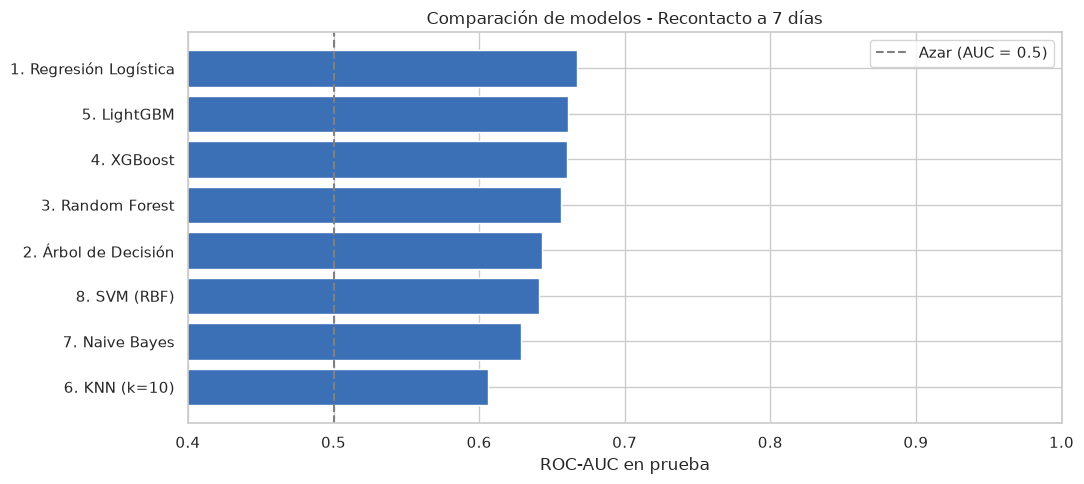

In [5]:
print("=" * 100)
print("📊 TABLA COMPARATIVA DE MODELOS - CASO 15 (RECONTACTO A 7 DÍAS)")
print("=" * 100)

# Formatear para visualización
df_display = df_resultados.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV ROC-AUC']:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")
df_display['CV Std'] = df_display['CV Std'].apply(lambda x: f"±{x:.4f}")
df_display['Tiempo (s)'] = df_display['Tiempo (s)'].apply(lambda x: f"{x:.2f}")

print(df_display.to_string(index=False))

# Destacar el mejor modelo
mejor_modelo = df_resultados.iloc[0]['Modelo']
mejor_auc = df_resultados.iloc[0]['ROC-AUC']

print(f"\n🏆 MEJOR MODELO: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_auc:.4f}")

# Guardar la tabla regenerable en el directorio de datos ignorado por Git
raiz_proyecto = os.path.abspath(os.path.join(RUTA_ANALITICA, '..', '..'))
if not os.path.isdir(os.path.join(raiz_proyecto, 'DataSetGenerator')):
    raiz_proyecto = RUTA_ANALITICA  # Dentro de Docker, /app es la raíz montada.
carpeta_salida = os.path.join(raiz_proyecto, 'data')
os.makedirs(carpeta_salida, exist_ok=True)
ruta_resultados = os.path.join(carpeta_salida, 'comparacion_modelos_caso15.csv')
df_resultados.to_csv(ruta_resultados, index=False, encoding='utf-8')
print(f"\n💾 Tabla guardada en {ruta_resultados}")

# Gráfico de barras del ROC-AUC
plt.figure(figsize=(11, 5))
orden = df_resultados.sort_values('ROC-AUC')
plt.barh(orden['Modelo'], orden['ROC-AUC'], color='#3b6fb6')
plt.axvline(0.5, color='gray', ls='--', label='Azar (AUC = 0.5)')
plt.xlim(0.4, 1.0)
plt.xlabel('ROC-AUC en prueba')
plt.title('Comparación de modelos - Recontacto a 7 días')
plt.legend()
plt.tight_layout()
plt.show()
